## Resolving Missing Values

In [1]:
import pandas as pd

###  1. order_approved_at column

In [2]:
main_df = pd.read_csv('../data/main_dataset.csv')

missing_order_approved_at = main_df[main_df['order_approved_at'].isnull()]
print("Total number of missing_value_rows: ", missing_order_approved_at.shape)
missing_order_approved_at[["order_id","order_status","order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]].head()

missing_order_approved_at['order_status'].unique()
main_df['order_status'].unique()

# Analyzing how many rows that are created, delivered
missing_order_approved_at[missing_order_approved_at['order_status'].isin(['created','delivered'])] # 20 rows
# Checking value counts of created and Delivered
missing_order_approved_at['order_status'].value_counts()
# Using temp to store delivered rows and analyze
temp = missing_order_approved_at[missing_order_approved_at["order_status"].isin(['delivered'])]
temp[["order_id","order_status","order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]]

# Getting not null values in delivered rows
approval_delay = main_df[main_df['order_approved_at'].notna()]
approval_delay.info()

# Data Correcting String to DateTime 
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])
main_df['order_approved_at'] = pd.to_datetime(main_df['order_approved_at'])

# Calculating the differnce of purchase and approval
approval_delay = (main_df['order_approved_at'] - main_df['order_purchase_timestamp'])
# Store the median value for relace
median_value_approval= approval_delay.median() # Timedelta('0 days 00:21:02')

# Replacing median in delivered rows
main_df.loc[
    (main_df['order_status'] == 'delivered') &
    (main_df['order_approved_at'].isna()),
    'order_approved_at'
] = (
    main_df.loc[
        (main_df['order_status'] == 'delivered') &
        (main_df['order_approved_at'].isna()),
        'order_purchase_timestamp'
    ] + median_value_approval
)

# Cross Check teh imputed values (it has now rows expected)
pd.DataFrame(main_df.loc[
    (main_df['order_status'] == 'delivered') & 
    (main_df['order_approved_at'].isna()),
    'order_approved_at'
])

# Analying created rows but according to business scnario it is not an data error  
main_df.loc[(main_df['order_status'] == 'created') & (main_df['order_approved_at'].isna()), :]

main_df['order_approved_at'].isnull().sum() # 146 expected


Total number of missing_value_rows:  (161, 37)
<class 'pandas.DataFrame'>
Index: 113264 entries, 0 to 113424
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113264 non-null  str    
 1   customer_id                    113264 non-null  str    
 2   order_status                   113264 non-null  str    
 3   order_purchase_timestamp       113264 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111442 non-null  str    
 6   order_delivered_customer_date  110181 non-null  str    
 7   order_estimated_delivery_date  113264 non-null  str    
 8   order_item_id                  112635 non-null  float64
 9   product_id                     112635 non-null  str    
 10  seller_id                      112635 non-null  str    
 11  shipping_limit_date            112635 non-null  str    
 12 

np.int64(146)

### 2. order_delivered_customer_data column

In [3]:
# Analyzing the missing values of order_delivered_custoemr_date
main_df['order_delivered_customer_date'].isnull().sum()

# Analyzing the status
main_df.loc[(main_df['order_delivered_customer_date'].isna()), 'order_status'].unique()
# Checking only deliverd rows because according to business logic delivered + no_delivered_customer_data is data error
delivered_rows = pd.DataFrame(main_df.loc[(main_df['order_delivered_customer_date'].isna()) & 
            (main_df['order_status'] == 'delivered'), :])
delivered_rows.shape
delivered_rows.loc[:, ["order_id","order_status","order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]]

# Data Correcting String to DateTime 
main_df['order_delivered_customer_date'] = pd.to_datetime(main_df['order_delivered_customer_date'])
main_df['order_delivered_carrier_date'] = pd.to_datetime(main_df['order_delivered_carrier_date'])

carrier_delay = (
    main_df['order_delivered_customer_date'] -
    main_df['order_delivered_carrier_date']
)

median_delay = carrier_delay.median()

main_df.loc[
    (main_df['order_delivered_customer_date'].isna()) & (~main_df['order_delivered_carrier_date'].isna()),
    'order_delivered_customer_date'
] = (
    main_df.loc[
        (main_df['order_delivered_customer_date'].isna()) & (~main_df['order_delivered_carrier_date'].isna()),
        'order_delivered_carrier_date'
    ] + median_delay
)

# Checking 7 rows updated expected it shows 1 row
pd.DataFrame(main_df.loc[(main_df['order_delivered_customer_date'].isna()) & 
            (main_df['order_status'] == 'delivered'), :]).loc[:, 
            ["order_id","order_status","order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
105606,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23 00:00:00


### 3. order_item_id column

In [ ]:
# Check how many missing values exist in order_item_id
main_df['order_item_id'].isna().sum()

# Display rows where order_item_id is missing
main_df.loc[
    main_df['order_item_id'].isna(),
    ['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp', 'price']
]

# Analyze missing values that belong to canceled or unavailable orders
main_df.loc[
    (main_df['order_item_id'].isna()) &
    (main_df['order_status'].isin(['canceled', 'unavailable']))
]

# Identify unexpected missing values in active orders
missing_value_rows = main_df.loc[
    (main_df['order_item_id'].isna()) &
    (~main_df['order_status'].isin(['canceled', 'unavailable']))
]

# Preview the rows that will be removed
missing_value_rows.head(8)

# Remove invalid rows (8 rows, negligible)
main_df = main_df.drop(missing_value_rows.index)

(113417, 37)

In [ ]:
# order_item_id                     767
# product_id                        767
# seller_id                         767
# shipping_limit_date               767
# price                             767
# freight_value                     767
# seller_zip_code_prefix            767
# seller_city                       767
# seller_state                      767
# since we handle missing values in order_item_id column then need not to investigate these columns because 
# these columns are dependent on order_item_id (root_cause)

In [ ]:
# Find rows where product_id exists but product attributes are missing
suspicious_products = main_df.loc[
    (main_df['product_id'].notna()) &
    (
        main_df['product_weight_g'].isna() |
        main_df['product_length_cm'].isna() |
        main_df['product_height_cm'].isna() |
        main_df['product_width_cm'].isna()
    )
]

print(suspicious_products.shape)

suspicious_products[
    [
        'product_id',
        'product_category_name',
        'product_name_lenght',
        'product_description_lenght',
        'product_photos_qty',
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm'
    ]
]

# Fill missing product categories with 'Not Specified'
main_df['product_category_name'] = main_df['product_category_name'].fillna('Not Specified')


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8353,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8805,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8806,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21517,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32096,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36206,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40760,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40761,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43692,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
46946,5eb564652db742ff8f28759cd8d2652a,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
main_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 141
order_delivered_carrier_date     1961
order_delivered_customer_date    1960
order_estimated_delivery_date       0
order_item_id                     767
product_id                        767
seller_id                         767
shipping_limit_date               767
price                             767
freight_value                     767
product_category_name               0
product_name_lenght              2370
product_description_lenght       2370
product_photos_qty               2370
product_weight_g                  785
product_length_cm                 785
product_height_cm                 785
product_width_cm                  785
seller_zip_code_prefix            767
seller_city                       767
seller_state                      767
payment_type_count                  3
used_credit_

In [ ]:
# Inspect rows where any of the three columns is missing
missing_product_info = main_df.loc[
    (
        main_df['product_name_lenght'].isna() |
        main_df['product_description_lenght'].isna() |
        main_df['product_photos_qty'].isna()
    ),
    [
        'product_id',
        'product_category_name',
        'product_name_lenght',
        'product_description_lenght',
        'product_photos_qty',
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm'
    ]
]

# Check all three columns missing in same row
missing_product_info.loc[
    (
        main_df['product_name_lenght'].isna() &
        main_df['product_description_lenght'].isna() &
        main_df['product_photos_qty'].isna()
    )]
#Since it was a metadata leave it has NaN and we can't completely
# delete the row because the row we loses other details

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
6,a1804276d9941ac0733cfd409f5206eb,Not Specified,NaN,NaN,NaN,600.0,35.0,35.0,15.0
122,71225f49be70df4297892f6a5fa62171,Not Specified,NaN,NaN,NaN,200.0,16.0,2.0,11.0
212,9820e04e332fc450d6fd975befc1bc28,Not Specified,NaN,NaN,NaN,10800.0,40.0,40.0,30.0
264,3bc5164bc7f4be77002d6651da65c98c,Not Specified,NaN,NaN,NaN,550.0,16.0,11.0,19.0
303,5a848e4ab52fd5445cdc07aab1c40e48,Not Specified,NaN,NaN,NaN,400.0,20.0,12.0,15.0
...,...,...,...,...,...,...,...,...,...
113204,NaN,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113236,NaN,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113324,NaN,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113325,NaN,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# checking null product_category_name and null product_category_name_english
main_df.loc[
    (main_df['product_category_name'].isna()) &
    (main_df['product_category_name_english'].isna()),
    ['product_category_name', 'product_category_name_english']
]

# replacing with Not Translated
main_df.loc[
    (main_df['product_category_name'].notna()) &
    (main_df['product_category_name_english'].isna()),
    ['product_category_name_english']] = 'Not Translated'


,product_category_name,product_category_name_english


## Column Name Correction

In [38]:
main_df.rename(
    columns={
        'product_name_lenght': 'product_name_length',
        'product_description_lenght': 'product_description_length'
    },
    inplace=True
)

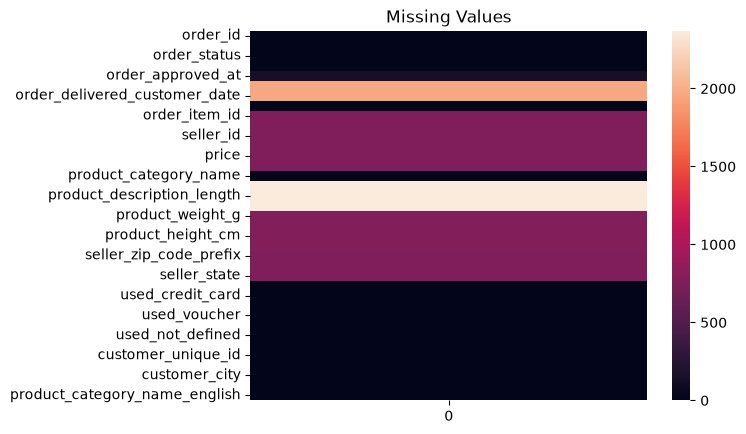

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_value = pd.DataFrame(main_df.isnull().sum())
sns.heatmap(data=missing_value)
plt.title("Missing Values")
plt.show()


In [48]:
# Creating the cleaned dataset
main_df.to_csv('../data/cleaned_dataset.csv', index=False)